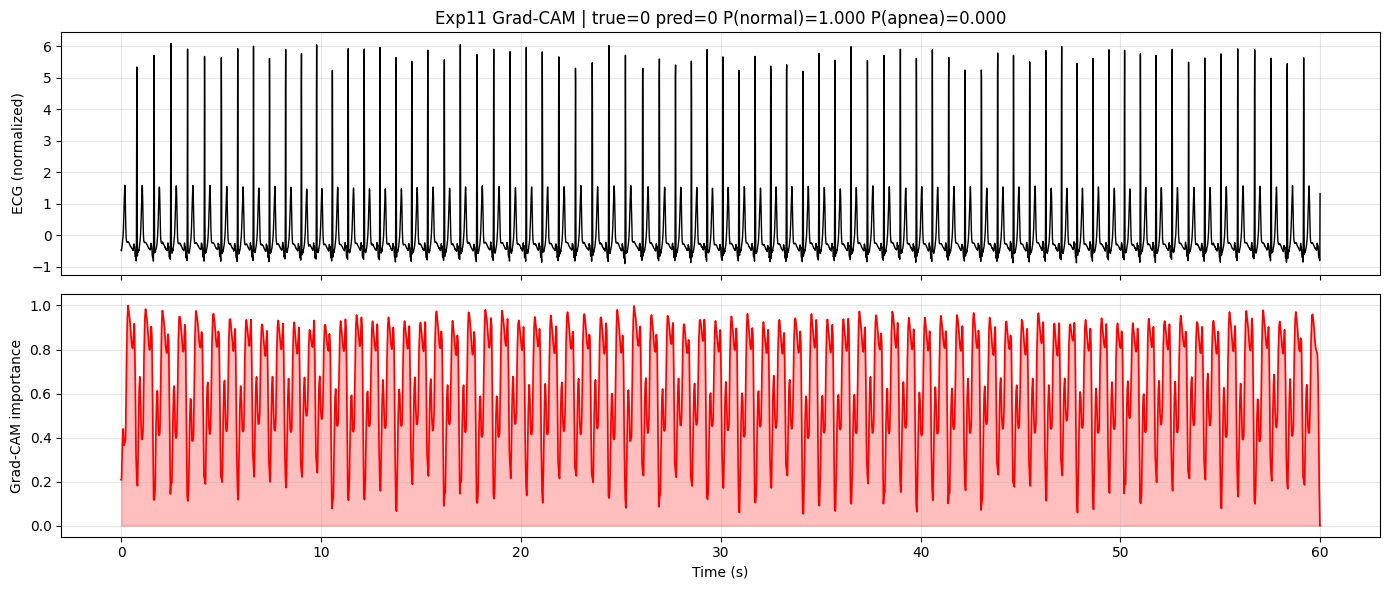

In [2]:
# Grad-CAM for exp11 model (CustomApneaModel)
# Prerequisite: run exp11 cells first so `model`, `test_loader`, and `device` exist.

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


def gradcam_exp11(model, x, target_layer=None, class_idx=None):
    """
    Compute 1D Grad-CAM from a 2D conv layer in CustomApneaModel.
    Returns: cam_1d (len=L), predicted_class, class_probabilities
    """
    if target_layer is None:
        # Last major 2D conv before PCSA sequence conversion
        target_layer = model.fuse.block[0]

    activations = {}
    gradients = {}

    def forward_hook(_module, _inputs, output):
        activations['value'] = output

    def backward_hook(_module, _grad_input, grad_output):
        gradients['value'] = grad_output[0]

    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_full_backward_hook(backward_hook)

    model.eval()
    model.zero_grad(set_to_none=True)

    logits = model(x)
    probs = torch.softmax(logits, dim=1)

    if class_idx is None:
        class_idx = int(torch.argmax(logits, dim=1).item())

    score = logits[:, class_idx].sum()
    score.backward()

    A = activations['value']     # [B, C, H, W]
    dA = gradients['value']      # [B, C, H, W]

    # Global-average pool gradients over spatial dimensions to get channel weights
    weights = dA.mean(dim=(2, 3), keepdim=True)       # [B, C, 1, 1]
    cam2d = (weights * A).sum(dim=1, keepdim=True)    # [B, 1, H, W]
    cam2d = torch.relu(cam2d)

    # Convert 2D CAM to 1D timeline: average H and upsample W -> input length
    cam1d = cam2d.mean(dim=2)  # [B, 1, W]
    cam1d = F.interpolate(cam1d, size=x.shape[-1], mode='linear', align_corners=False)
    cam1d = cam1d.squeeze(0).squeeze(0).detach().cpu().numpy()

    cam1d = cam1d - cam1d.min()
    cam1d = cam1d / (cam1d.max() + 1e-8)

    h1.remove()
    h2.remove()

    return cam1d, class_idx, probs.detach().cpu().numpy()[0]


# ---- Example usage ----
# Choose a sample from test_loader
batch_index = 0
sample_index_in_batch = 0
fs = 100.0  # exp11 segmentation fs

for i, (X_batch, y_batch) in enumerate(test_loader):
    if i == batch_index:
        x = X_batch[sample_index_in_batch:sample_index_in_batch + 1].to(device)
        y_true = int(y_batch[sample_index_in_batch].item())
        break
else:
    raise ValueError(f'Batch index {batch_index} out of range for test_loader')

cam, pred_class, prob = gradcam_exp11(model, x)
sig = x.squeeze().detach().cpu().numpy()
time_axis = np.arange(sig.shape[0]) / fs

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(time_axis, sig, color='black', linewidth=1.0)
axes[0].set_ylabel('ECG (normalized)')
axes[0].set_title(
    f'Exp11 Grad-CAM | true={y_true} pred={pred_class} '
    f'P(normal)={prob[0]:.3f} P(apnea)={prob[1]:.3f}'
)
axes[0].grid(alpha=0.3)

axes[1].plot(time_axis, cam, color='red', linewidth=1.2)
axes[1].fill_between(time_axis, 0, cam, color='red', alpha=0.25)
axes[1].set_ylabel('Grad-CAM importance')
axes[1].set_xlabel('Time (s)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
